In [120]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
def f(x):
    return 3*x**2 - 4*x +5

In [5]:
f(3.0)

20.0

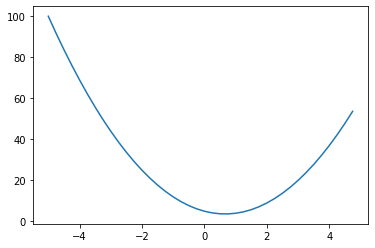

In [14]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [19]:
h = 0.01
x = -3.0
f(x + h)
(f(x + h) - f(x)) / h

-21.9699999999996

In [20]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [ ]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
a += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slop', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slop -3.000000000010772


In [131]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad = 1.0 * out.grad
            other.grad = 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad = other.data * out.grad
            other.grad = self.data * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        
        return out


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label ='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [122]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

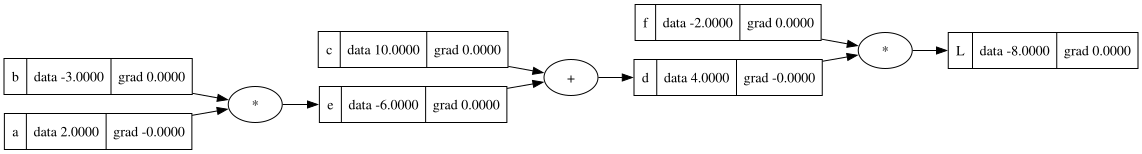

In [123]:
draw_dot(L)

In [79]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f; L.label = 'L'
print(L.data)

-7.4352


In [75]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

In [76]:
c.grad = -2.0
e.grad = -2.0

L = d*f
dL/dd = ?f

(f(x+h) - f(x))/h 
((d+h)*f - d*f)/h
(h*f)/h 
f

In [60]:
f.grad = 4.0
d.grad = -2.0

# chain rule

dL / dc = 1.0
dL / de = 1.0

d = c + e

(f(x+h) - f(x))/h 

((c+h + e) - (c + e))/h 
h / h 
1.0

WANT:
dL / dc = (dl / dd) * (dd / dc)

KNOW:
dL / dd
dd / dc




dL / de = -2.0

e = a * b 
de / da = b

dL / da = (dL / de) * (de / da)

In [65]:
def lol():
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label ='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    d.data += h
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data

    print((L2 - L1)/h)

lol()

-1.9999999999953388


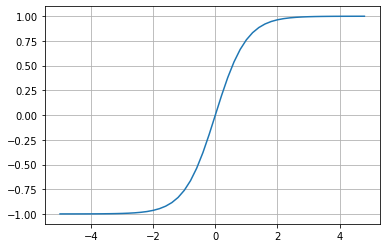

In [80]:
# sigmod tanh
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

In [132]:
# input x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

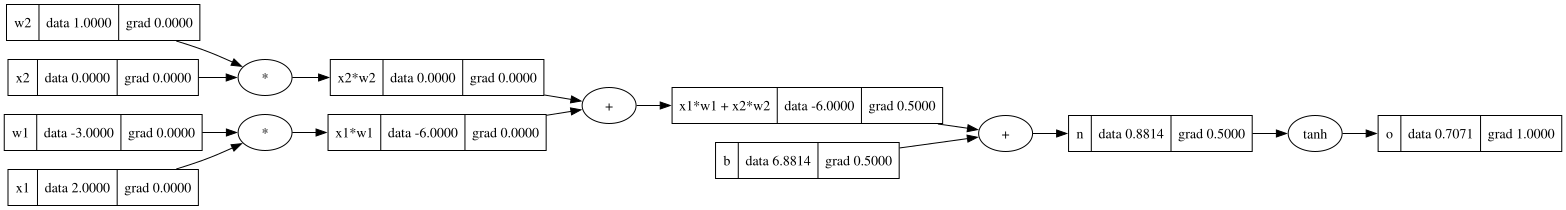

In [139]:
draw_dot(o)

In [134]:
o.grad = 1.0


In [136]:
o._backward()

In [138]:
n._backward()

In [ ]:
b._backward()

In [118]:
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad

In [116]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

In [114]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [112]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [107]:
# o = tanh(n)
# do/dn = 1 - o**2
n.grad = 0.5

In [110]:
o.grad = 1.0

In [111]:
1 - o.data**2

0.4999999999999999

In [ ]:
# o = tanh(n)
# do/dn = 1 - o**2